# Notebook 2: Measures of Central Tendency

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is Central Tendency?

A measure of central tendency is a single value that represents the "center" or "typical value" of a dataset. Instead of looking at thousands of numbers, we summarize them with one number.

**Analogy:** If a teacher says "the class average is 72", you get a quick picture of the whole class without reading every student's mark.

**Measures covered:** Mean, Median, Mode, Weighted Mean, Geometric Mean, Harmonic Mean.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
from scipy import stats

## 1. Mean (Arithmetic Mean)

**Definition:** The mean is the sum of all values divided by the number of values. It is the "balance point" of the data.

**Formula:**

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

**Numerical Example:** Marks = 60, 70, 80, 90, 100
Sum = 400, n = 5, Mean = 400 / 5 = **80**

**Business Example:** A retail store finds the average daily sales over a month to plan stock and staffing.

**AI/ML Example:** Mean is used to fill missing values (mean imputation), in feature scaling (standardization subtracts the mean), and in Mean Squared Error for model evaluation.

In [2]:
marks = [60, 70, 80, 90, 100]

# Manual calculation
mean_manual = sum(marks) / len(marks)

# Using NumPy
mean_numpy = np.mean(marks)

print("Manual mean:", mean_manual)
print("NumPy mean :", mean_numpy)

Manual mean: 80.0
NumPy mean : 80.0


**Explanation:** The program adds all marks and divides by the count, first manually and then using `np.mean()`. Both give the same result.

**Interpretation:** The mean mark is 80, so a typical student scored around 80. The mean uses every value, so it is sensitive to extreme values (outliers).

## 2. Median

**Definition:** The median is the middle value when the data is sorted in order. Half of the values are below it and half above it.

**Formula:**
- If n is odd: Median = value at position (n + 1) / 2
- If n is even: Median = average of the two middle values

**Numerical Example:** Salaries = 25000, 28000, 30000, 32000, 35000, 200000
n = 6 (even). Middle values are 30000 and 32000.
Median = (30000 + 32000) / 2 = **31000**

**Business Example:** Governments report median household income because a few billionaires would push the mean up and mislead the picture.

**AI/ML Example:** Median imputation is used to fill missing values in skewed features (like income or house price), because the median is not affected by outliers.

In [3]:
salaries = [25000, 28000, 30000, 32000, 35000, 200000]

mean_salary = np.mean(salaries)
median_salary = np.median(salaries)

print("Mean salary  :", round(mean_salary, 2))
print("Median salary:", median_salary)

Mean salary  : 58333.33
Median salary: 31000.0


**Explanation:** The data has one extreme salary (200000). `np.mean()` and `np.median()` are calculated for comparison.

**Interpretation:** The mean (about 58333) is pulled up by the outlier and does not represent a typical employee. The median (31000) is a much better summary. **When data has outliers or is skewed, prefer the median.**

## 3. Mode

**Definition:** The mode is the value that occurs most frequently in the data. A dataset can have one mode (unimodal), two modes (bimodal), or more.

**Formula:** Mode = value with the highest frequency (no arithmetic formula).

**Numerical Example:** Data = 2, 3, 3, 4, 5, 3, 6
The value 3 appears 3 times, so Mode = **3**

**Business Example:** A clothing store finds the most-sold shirt size (mode = M) to decide which size to stock more.

**AI/ML Example:** Mode imputation fills missing values in categorical features (such as city or gender) with the most frequent category. It is also used for majority voting in classification (for example, KNN and Random Forest).

In [4]:
data = [2, 3, 3, 4, 5, 3, 6]

print("Mode:", statistics.mode(data))

# Categorical example
sizes = pd.Series(["M", "L", "M", "S", "M", "L", "XL"])
print("Most sold size:", sizes.mode()[0])
print("\nFrequency count:\n", sizes.value_counts())

Mode: 3
Most sold size: M

Frequency count:
 M     3
L     2
S     1
XL    1
Name: count, dtype: int64


**Explanation:** `statistics.mode()` returns the most frequent number. For categorical data we use pandas `mode()` and `value_counts()`.

**Interpretation:** The mode is 3 for numbers and "M" for shirt sizes. Mode is the only measure of central tendency that works for **categorical** data, because we cannot calculate a mean or median of text labels.

## 4. Weighted Mean

**Definition:** The weighted mean is an average where each value has a different importance (weight). Values with higher weights contribute more to the result.

**Formula:**

$$\bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}$$

**Numerical Example:** A student's subject marks and credits:

| Subject | Marks (x) | Credits (w) | w × x |
|---|---|---|---|
| Maths | 80 | 3 | 240 |
| Science | 90 | 4 | 360 |
| English | 70 | 2 | 140 |

Weighted mean = (240 + 360 + 140) / (3 + 4 + 2) = 740 / 9 = **82.22**

**Business Example:** A company calculates the average price of a product bought in different quantities from different suppliers, where quantity is the weight.

**AI/ML Example:** Weighted averages are used in ensemble models (giving a better model more weight), in class weights for imbalanced data, and in the weighted loss functions of neural networks.

In [5]:
marks = [80, 90, 70]
credits = [3, 4, 2]

# Manual calculation
weighted_manual = sum(m * c for m, c in zip(marks, credits)) / sum(credits)

# Using NumPy
weighted_numpy = np.average(marks, weights=credits)

simple_mean = np.mean(marks)

print("Simple mean       :", round(simple_mean, 2))
print("Weighted mean (manual):", round(weighted_manual, 2))
print("Weighted mean (numpy) :", round(weighted_numpy, 2))

Simple mean       : 80.0
Weighted mean (manual): 82.22
Weighted mean (numpy) : 82.22


**Explanation:** Each mark is multiplied by its credit, all products are added, and the total is divided by the sum of credits. `np.average(..., weights=...)` does the same.

**Interpretation:** The simple mean is 80, but the weighted mean is 82.22. Science has the highest credits and the highest marks, so it pulls the result up. **Use a weighted mean when values do not have equal importance.**

## 5. Geometric Mean

**Definition:** The geometric mean is the nth root of the product of n values. It is used for data that multiplies or grows over time (growth rates, ratios, percentages). All values must be positive.

**Formula:**

$$GM = \left(\prod_{i=1}^{n} x_i\right)^{1/n} = \sqrt[n]{x_1 \times x_2 \times \dots \times x_n}$$

**Numerical Example:** An investment grows by 10%, 20% and 30% in three years. Growth factors = 1.10, 1.20, 1.30
Product = 1.10 × 1.20 × 1.30 = 1.716
GM = 1.716^(1/3) ≈ **1.1972**, which means about **19.72%** average yearly growth.
(The arithmetic mean would say 20%, which is slightly wrong.)

**Business Example:** Calculating the average annual return of an investment or the compound annual growth rate (CAGR) of company revenue.

**AI/ML Example:** Used in the geometric mean of ratios when comparing model performance across different datasets, and in G-Mean, a metric for imbalanced classification.

In [6]:
growth_factors = [1.10, 1.20, 1.30]

# Manual calculation
gm_manual = np.prod(growth_factors) ** (1 / len(growth_factors))

# Using SciPy
gm_scipy = stats.gmean(growth_factors)

print("Geometric mean (manual):", round(gm_manual, 4))
print("Geometric mean (scipy) :", round(gm_scipy, 4))
print("Average growth rate    :", round((gm_scipy - 1) * 100, 2), "%")
print("Arithmetic mean        :", round(np.mean(growth_factors), 4))

# Verify: investing 1000
print("\nActual final value of 1000:", round(1000 * np.prod(growth_factors), 2))
print("Using GM for 3 years      :", round(1000 * gm_scipy ** 3, 2))

Geometric mean (manual): 1.1972
Geometric mean (scipy) : 1.1972
Average growth rate    : 19.72 %
Arithmetic mean        : 1.2

Actual final value of 1000: 1716.0
Using GM for 3 years      : 1716.0


**Explanation:** We multiply all growth factors, take the cube root (n = 3) and convert it into a percentage. SciPy's `gmean()` gives the same answer.

**Interpretation:** The true average yearly growth is about 19.72%, and using this rate for 3 years gives exactly the real final value (1716). The arithmetic mean (20%) would overestimate. **Use the geometric mean for growth rates and compounding values.**

## 6. Harmonic Mean

**Definition:** The harmonic mean is the reciprocal of the average of reciprocals. It is used for rates and ratios (speed, price per unit), especially when the numerator is fixed. All values must be positive.

**Formula:**

$$HM = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}$$

**Numerical Example:** A car travels the same distance at 40 km/h and then at 60 km/h.
HM = 2 / (1/40 + 1/60) = 2 / 0.041667 = **48 km/h**
(The arithmetic mean would wrongly say 50 km/h.)

**Business Example:** Finding the average speed for a delivery trip with equal distances at different speeds, or the average price when a fixed amount of money is spent on a product at different prices.

**AI/ML Example:** The **F1-Score** is the harmonic mean of Precision and Recall. It punishes a model that is good at one but bad at the other.

$$F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}$$

In [7]:
speeds = [40, 60]

# Manual calculation
hm_manual = len(speeds) / sum(1 / s for s in speeds)

# Using SciPy and statistics
hm_scipy = stats.hmean(speeds)

print("Harmonic mean (manual):", round(hm_manual, 2))
print("Harmonic mean (scipy) :", round(hm_scipy, 2))
print("Arithmetic mean       :", np.mean(speeds))

# AI/ML example: F1 score
precision = 0.8
recall = 0.6
f1 = stats.hmean([precision, recall])

print("\nPrecision:", precision, "| Recall:", recall)
print("F1-score (harmonic mean):", round(f1, 4))
print("Simple average          :", (precision + recall) / 2)

Harmonic mean (manual): 48.0
Harmonic mean (scipy) : 48.0
Arithmetic mean       : 50.0

Precision: 0.8 | Recall: 0.6
F1-score (harmonic mean): 0.6857
Simple average          : 0.7


**Explanation:** The code takes the reciprocal of each value, averages them and inverts the result. Then we apply the same idea to Precision and Recall to get the F1-score.

**Interpretation:** The true average speed is 48 km/h, not 50, because the car spends more time at the slower speed. The F1-score (0.6857) is lower than the simple average (0.70), because the harmonic mean is pulled toward the smaller value. **Use the harmonic mean for rates and averaging ratios like Precision and Recall.**

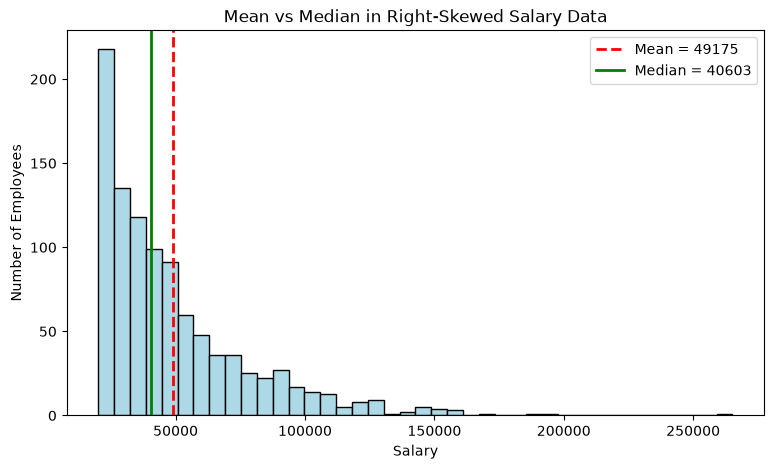

In [8]:
# Skewed salary data: mean vs median vs mode
np.random.seed(42)
salary_data = np.random.exponential(scale=30000, size=1000) + 20000

mean_v = np.mean(salary_data)
median_v = np.median(salary_data)

plt.figure(figsize=(9, 5))
plt.hist(salary_data, bins=40, color="lightblue", edgecolor="black")
plt.axvline(mean_v, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_v:.0f}")
plt.axvline(median_v, color="green", linestyle="-", linewidth=2, label=f"Median = {median_v:.0f}")
plt.title("Mean vs Median in Right-Skewed Salary Data")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.legend()
plt.show()

**Explanation:** We generate right-skewed salary data (many low salaries, few very high ones) and draw the mean and median as vertical lines on a histogram.

**Interpretation:** The mean (red) is to the right of the median (green), because high salaries pull the mean up. In a skewed distribution, the median represents the typical person better.

| Distribution shape | Relationship |
|---|---|
| Symmetric | Mean = Median = Mode |
| Right-skewed | Mean > Median > Mode |
| Left-skewed | Mean < Median < Mode |

## Summary: Which Measure to Use?

| Measure | Best used when | Affected by outliers? |
|---|---|---|
| Mean | Data is symmetric, no outliers | Yes |
| Median | Data is skewed or has outliers | No |
| Mode | Categorical data, most common value | No |
| Weighted Mean | Values have different importance | Depends on weights |
| Geometric Mean | Growth rates, compounding, ratios | Less than the mean |
| Harmonic Mean | Rates, speeds, Precision and Recall | Strongly pulled to small values |

## Advantages
- Summarizes large data into a single, easy-to-understand number
- Makes comparison between groups or datasets simple
- Forms the base for variance, standard deviation and many ML algorithms
- Each measure suits a different type of data

## Limitations
- Mean is heavily affected by outliers
- Median ignores the actual values of other data points
- Mode may not exist or may have multiple values
- Geometric and harmonic means need positive values only
- One number alone cannot describe the spread of data (we need dispersion, covered in Notebook 3)